# MultiStreamCNN — Hyperparameter Grid Search

Systematic study of three dimensions, motivated by the architecture in `CNN_multichannel.ipynb`:

| Dimension | Values searched |
|---|---|
| `kernel_nb` — behaviour-branch temporal receptive field | 7, 15, 31 |
| `kernel_ns` — stimulus-branch temporal receptive field | 5, 7, 15 |
| filter budget `(k_nb, k_ns, k_all)` | (32,32,16), (48,48,32), (64,64,32), (96,96,48) |
| `dropout` | 0.3, 0.4 |

Fixed across all configs: `kernel_all=7`, backbone 128→256, lr=3e-4, batch=128, patience=10.
Results are saved incrementally to `gridsearch_results.csv` so the run can be interrupted and resumed.

In [1]:
%reload_ext autoreload
%autoreload 2

import sys, os, warnings, importlib, subprocess, time, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, ConfusionMatrixDisplay,
)

import microns_datacleaner as mic
import microns_datacleaner.filters as fl

warnings.filterwarnings('ignore')
np.random.seed(42)

def _find_root():
    p = Path.cwd()
    while p != p.parent:
        if (p / 'microns.h5').exists():
            return p
        p = p.parent
    p = Path.cwd()
    while p != p.parent:
        if (p / 'data' / '1718' / 'raw').exists():
            return p
        p = p.parent
    raise RuntimeError('Cannot find workspace root.')

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
TOMMY_DIR = Path('..').resolve()
if str(TOMMY_DIR) not in sys.path:
    sys.path.insert(0, str(TOMMY_DIR))

RESULTS_CSV = Path(__file__).parent / 'gridsearch_results.csv' if '__file__' in dir() else Path('gridsearch_results.csv')
print(f'Workspace root: {ROOT}')
print(f'Results will be saved to: {RESULTS_CSV}')

Workspace root: c:\Users\tomma\Desktop\NEUROSCIENCE
Results will be saved to: gridsearch_results.csv


In [2]:
cleaner = mic.MicronsDataCleaner(
    datadir=os.path.relpath(str(ROOT / 'data')),
    version=1718,
    download_policy='minimum',
)
units_match, _ = cleaner.process_nucleus_data(functional_data='match')

matched = fl.filter_neurons(
    units_match,
    tuning='matched',
    cell_type='excitatory_neuron',
    brain_area='V1',
).copy()

unit_id_col = None
for col_name in ['functional_unit_id', 'unit_id', 'index', 'neuron_idx', 'neuron_id']:
    if col_name in matched.columns:
        unit_id_col = col_name
        break
if unit_id_col is None:
    raise ValueError(f'No usable neuron index column. Available: {list(matched.columns)}')

print(f'Matched neurons: {len(matched)}  |  unit_id_col: {unit_id_col}')
print(matched['layer'].value_counts(dropna=False).sort_index().to_string())

Transform positions: 100%|██████████| 94014/94014 [00:01<00:00, 90828.29it/s]


Matched neurons: 13044  |  unit_id_col: functional_unit_id
layer
L1        16
L2/3    6340
L4      3941
L5      2269
L6       478


In [3]:
from reader import MicronsReader

H5_CANDIDATES = [
    ROOT / 'microns.h5',
    ROOT / 'data' / 'functional' / 'microns_functional.h5',
]
functional_path = next((p for p in H5_CANDIDATES if p.exists()), None)
if functional_path is None:
    raise FileNotFoundError(f'No functional H5 found. Tried: {H5_CANDIDATES}')

print(f'Using: {functional_path}')
funcreader   = MicronsReader(str(functional_path))
session_keys = list(funcreader.f['sessions'].keys())

scan_rows = []
for k in session_keys:
    parts = k.split('_')
    if len(parts) == 2:
        try:
            scan_rows.append((int(parts[0]), int(parts[1]), k))
        except ValueError:
            pass

scan_df = (
    pd.DataFrame(scan_rows, columns=['session', 'scan_idx', 'key'])
    .sort_values(['session', 'scan_idx'])
    .reset_index(drop=True)
)
print(f'Session/scan keys: {len(scan_df)}')

Using: c:\Users\tomma\Desktop\NEUROSCIENCE\microns.h5
Session/scan keys: 14


In [4]:
def zscore_1d(x, eps=1e-8):
    x = np.asarray(x, dtype=np.float32)
    m, s = np.nanmean(x), np.nanstd(x)
    if not np.isfinite(s) or s < eps:
        return np.zeros_like(x)
    return (x - m) / (s + eps)

def resample_to(arr, target_len):
    arr = np.asarray(arr, dtype=np.float32).ravel()
    if arr.size == target_len:
        return arr
    return np.interp(
        np.linspace(0, 1, target_len),
        np.linspace(0, 1, arr.size),
        arr,
    ).astype(np.float32)

def extract_stim_channels(clip, target_len):
    frames = clip.astype(np.float32)
    if frames.ndim != 3:
        return np.zeros((7, target_len), dtype=np.float32)
    F, H, W = frames.shape
    eps = 1e-8
    pix = frames.reshape(F, -1)
    mean_intensity = pix.mean(1);  std_intensity = pix.std(1)
    if F > 1:
        d = np.abs(np.diff(frames, axis=0))
        motion_energy = np.concatenate([[0.], d.reshape(F-1,-1).mean(1)])
    else:
        motion_energy = np.zeros(F, dtype=np.float32)
    grad_energy = np.zeros(F, dtype=np.float32)
    edge_fraction = np.zeros(F, dtype=np.float32)
    for i in range(F):
        gy, gx = np.gradient(frames[i])
        gm = np.sqrt(gx*gx + gy*gy)
        grad_energy[i] = gm.mean()
        edge_fraction[i] = (gm > np.percentile(gm, 85)).mean()
    h0,h1 = H//4,(3*H)//4;  w0,w1 = W//4,(3*W)//4
    center = frames[:,h0:h1,w0:w1]
    center_mean = center.reshape(F,-1).mean(1)
    surround_n  = H*W - (h1-h0)*(w1-w0)
    surround_mean = (pix.sum(1) - center.reshape(F,-1).sum(1)) / max(surround_n,1)
    center_surround = center_mean - surround_mean
    norm_contrast = std_intensity / (mean_intensity + eps)
    raw = [mean_intensity, std_intensity, motion_energy,
           grad_energy, edge_fraction, center_surround, norm_contrast]
    result = np.zeros((7, target_len), dtype=np.float32)
    for i, ch in enumerate(raw):
        result[i] = zscore_1d(resample_to(ch, target_len))
    return result

def extract_behaviour_channels(trial, target_len):
    result = np.zeros((4, target_len), dtype=np.float32)
    treadmill = np.asarray(trial['treadmill'], dtype=np.float32).ravel()
    treadmill = np.where(np.isfinite(treadmill), treadmill, 0.)
    result[0] = zscore_1d(resample_to(treadmill, target_len))
    pupil = np.asarray(trial['pupil'], dtype=np.float32)
    if pupil.ndim == 2:
        if pupil.shape[1] == 3:
            pupil = pupil.T
        if pupil.shape[0] >= 3:
            for i in range(3):
                ch = np.where(np.isfinite(pupil[i]), pupil[i], 0.)
                result[1+i] = zscore_1d(resample_to(ch, target_len))
    elif pupil.ndim == 1 and pupil.size > 0:
        ch = np.where(np.isfinite(pupil), pupil, 0.)
        result[3] = zscore_1d(resample_to(ch, target_len))
    return result

In [5]:
MAX_TRIALS_PER_SCAN = 8
MIN_TRACE_LEN       = 60
TARGET_LEN          = 300
EXCLUDE_LAYERS      = {'L1'}
N_CHANNELS          = 12

STIM_CHANNEL_NAMES = ['stim_mean','stim_std','stim_motion','stim_grad',
                       'stim_edge_frac','stim_center_surround','stim_norm_contrast']
BEH_CHANNEL_NAMES  = ['treadmill','pupil_x','pupil_y','pupil_size']
CHANNEL_NAMES      = ['neural_response'] + STIM_CHANNEL_NAMES + BEH_CHANNEL_NAMES

neuron_key_col = 'target_id' if 'target_id' in matched.columns else unit_id_col
print(f'Neuron identity column: {neuron_key_col}')

neuron_records = {}
clip_cache     = {}

matched_scans = matched[['session','scan_idx']].dropna().drop_duplicates().copy()
matched_scans['session']  = matched_scans['session'].astype(int)
matched_scans['scan_idx'] = matched_scans['scan_idx'].astype(int)

scan_candidates = (
    scan_df.merge(matched_scans, on=['session','scan_idx'], how='inner')
    .sort_values(['session','scan_idx']).reset_index(drop=True)
)
print(f'Candidate session/scan pairs: {len(scan_candidates)}')

for _, srow in scan_candidates.iterrows():
    session  = int(srow['session'])
    scan_idx = int(srow['scan_idx'])
    key      = srow['key']

    session_neurons = matched[
        (matched['session'] == session) & (matched['scan_idx'] == scan_idx)
    ].copy().dropna(subset=[unit_id_col,'layer',neuron_key_col])
    session_neurons['layer'] = session_neurons['layer'].astype(str)
    session_neurons = session_neurons[~session_neurons['layer'].isin(EXCLUDE_LAYERS)]
    if session_neurons.empty:
        continue

    hashes = funcreader.get_hashes_by_session(key)
    if len(hashes) == 0:
        continue

    unit_ids       = funcreader.f[f'sessions/{key}/meta/unit_ids'][:]
    unit_id_to_row = {int(u): idx for idx, u in enumerate(unit_ids)}
    n_trials       = min(len(hashes), MAX_TRIALS_PER_SCAN)

    for t in range(n_trials):
        try:
            td = funcreader.get_trial(key, t)
        except (ValueError, KeyError):
            continue
        if td is None:
            continue

        cond_hash = hashes[t]
        if cond_hash not in clip_cache:
            clip, _ = funcreader.get_video_data(cond_hash)
            clip_cache[cond_hash] = extract_stim_channels(clip, TARGET_LEN) if clip is not None else None

        stim_channels = clip_cache[cond_hash]
        beh_channels  = extract_behaviour_channels(td, TARGET_LEN)
        responses     = td['responses']

        for _, nr in session_neurons.iterrows():
            neuron_key = int(nr[neuron_key_col])
            if neuron_key in neuron_records:
                continue
            fuid    = int(nr[unit_id_col])
            row_idx = unit_id_to_row.get(fuid)
            if row_idx is None or row_idx >= responses.shape[0]:
                continue
            trace = np.asarray(responses[row_idx,:], dtype=np.float32).ravel()
            trace = trace[np.isfinite(trace)]
            if trace.size < MIN_TRACE_LEN:
                continue
            trace = zscore_1d(resample_to(trace, TARGET_LEN))
            multichan = np.zeros((N_CHANNELS, TARGET_LEN), dtype=np.float32)
            multichan[0] = trace
            if stim_channels is not None:
                multichan[1:8] = stim_channels
            multichan[8:12] = beh_channels
            neuron_records[neuron_key] = {
                'neuron_key': neuron_key, 'layer': str(nr['layer']),
                'multichan': multichan, 'unit_id': fuid,
            }

records = list(neuron_records.values())
print(f'Total unique neuron samples: {len(records)}')
print(pd.Series([r['layer'] for r in records]).value_counts().sort_index().to_string())

Neuron identity column: functional_unit_id
Candidate session/scan pairs: 14
Total unique neuron samples: 6548
L2/3    2704
L4      2072
L5      1425
L6       347


In [6]:
neuron_df = pd.DataFrame([
    {'neuron_key': r['neuron_key'], 'layer': r['layer']} for r in records
]).drop_duplicates(subset=['neuron_key'])

layer_counts = neuron_df['layer'].value_counts()
keep_layers  = layer_counts[layer_counts >= 20].index.tolist()
neuron_df    = neuron_df[neuron_df['layer'].isin(keep_layers)].copy()

TARGET_TRAIN_SAMPLES = 6000
test_size    = 0.25
total_target = int(round(TARGET_TRAIN_SAMPLES / (1 - test_size)))

if len(neuron_df) > total_target:
    _, neuron_df = train_test_split(
        neuron_df, train_size=total_target,
        random_state=42, stratify=neuron_df['layer'].values,
    )
    neuron_df = neuron_df.reset_index(drop=True)

train_neurons, test_neurons = train_test_split(
    neuron_df['neuron_key'].values, test_size=test_size,
    random_state=42, stratify=neuron_df['layer'].values,
)
train_set = set(train_neurons)
test_set  = set(test_neurons)

enc = LabelEncoder()
enc.fit(neuron_df['layer'])

def build_split(neuron_keys_set):
    X, y, uids = [], [], []
    for r in records:
        if r['neuron_key'] not in neuron_keys_set or r['layer'] not in keep_layers:
            continue
        X.append(r['multichan']);  y.append(r['layer']);  uids.append(r['neuron_key'])
    return np.asarray(X, dtype=np.float32), enc.transform(y), np.array(uids)

X_train, y_train, uids_train = build_split(train_set)
X_test,  y_test,  uids_test  = build_split(test_set)
n_classes = len(enc.classes_)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Classes: {enc.classes_}')

Train: (4911, 12, 300)  |  Test: (1637, 12, 300)
Classes: ['L2/3' 'L4' 'L5' 'L6']


In [7]:
if importlib.util.find_spec('torch') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', 'torch',
                           '--index-url', 'https://download.pytorch.org/whl/cpu'])

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | device: {DEVICE}')

BATCH_SIZE = 128
class_counts  = np.bincount(y_train, minlength=n_classes).astype(np.float32)
class_weights = torch.tensor(1. / (class_counts + 1e-8)).to(DEVICE)
class_weights /= class_weights.sum()

def make_loader(X, y, shuffle):
    return DataLoader(
        TensorDataset(torch.tensor(X, dtype=torch.float32),
                      torch.tensor(y, dtype=torch.long)),
        batch_size=BATCH_SIZE, shuffle=shuffle, drop_last=False,
    )

train_loader = make_loader(X_train, y_train, shuffle=True)
test_loader  = make_loader(X_test,  y_test,  shuffle=False)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

PyTorch 2.11.0+cpu | device: cpu
Train batches: 39 | Test batches: 13


In [8]:
class FlexibleMultiStreamCNN(nn.Module):
    NB_IDX  = [0, 8, 9, 10, 11]   # neural + behaviour
    NS_IDX  = list(range(8))       # neural + stimulus
    ALL_IDX = list(range(12))      # all channels

    def __init__(self, n_channels, seq_len, n_classes,
                 k_nb=48, k_ns=48, k_all=32,
                 kernel_nb=7, kernel_ns=7, kernel_all=7,
                 dropout=0.4):
        super().__init__()

        def _branch(in_ch, out_ch, ks):
            return nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=ks, padding=ks//2, bias=False),
                nn.BatchNorm1d(out_ch), nn.ReLU(True), nn.MaxPool1d(2),
            )

        self.branch_nb  = _branch(len(self.NB_IDX),  k_nb,  kernel_nb)
        self.branch_ns  = _branch(len(self.NS_IDX),  k_ns,  kernel_ns)
        self.branch_all = _branch(len(self.ALL_IDX), k_all, kernel_all)

        fused = k_nb + k_ns + k_all

        # Fixed-width backbone (same as ShallowCNN blocks 2-3)
        self.backbone = nn.Sequential(
            nn.Conv1d(fused, 128, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm1d(128), nn.ReLU(True), nn.MaxPool1d(2),
            nn.Conv1d(128,   256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(256), nn.ReLU(True), nn.MaxPool1d(2),
        )
        flat = 256 * (seq_len // 8)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat, 256), nn.ReLU(True), nn.Dropout(dropout),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        nb   = self.branch_nb (x[:, self.NB_IDX,  :])
        ns   = self.branch_ns (x[:, self.NS_IDX,  :])
        all_ = self.branch_all(x[:, self.ALL_IDX, :])
        return self.head(self.backbone(torch.cat([nb, ns, all_], dim=1)))

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

# Sanity-check with baseline config
_test = FlexibleMultiStreamCNN(N_CHANNELS, TARGET_LEN, n_classes).to(DEVICE)
_x    = torch.zeros(4, N_CHANNELS, TARGET_LEN).to(DEVICE)
assert _test(_x).shape == (4, n_classes), "forward pass shape mismatch"
print(f'FlexibleMultiStreamCNN (baseline config) params: {count_params(_test):,}')
print('Forward pass OK.')

FlexibleMultiStreamCNN (baseline config) params: 2,614,420
Forward pass OK.


In [9]:
def train_model(model, train_loader, test_loader, *,
                lr=3e-4, weight_decay=1e-4,
                max_epochs=80, patience=10,
                label='model', verbose=True):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=max_epochs)

    history       = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_state    = None
    patience_cnt  = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimiser.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimiser.step()
            running_loss += loss.item() * xb.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss, correct = 0., 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits    = model(xb)
                val_loss += criterion(logits, yb).item() * xb.size(0)
                correct  += (logits.argmax(1) == yb).sum().item()
        val_loss /= len(test_loader.dataset)
        val_acc   = correct / len(test_loader.dataset)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt  = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                if verbose:
                    print(f'[{label}] Early stop at epoch {epoch}')
                break

        if verbose:
            print(f'[{label}] Epoch {epoch:3d} | train={train_loss:.4f}  val={val_loss:.4f}  acc={val_acc:.3f}')

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    return history


def evaluate(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in loader:
            preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
    return np.concatenate(preds)

In [10]:
# Grid dimensions
GRID = {
    'kernel_nb': [7, 15, 31],                               # behaviour branch TRF
    'kernel_ns': [5, 7, 15],                                # stimulus branch TRF
    'filters':   [(32,32,16), (48,48,32), (64,64,32), (96,96,48)],  # (k_nb, k_ns, k_all)
    'dropout':   [0.3, 0.4],
}

GS_MAX_EPOCHS = 80
GS_PATIENCE   = 10

configs = list(itertools.product(
    GRID['kernel_nb'],
    GRID['kernel_ns'],
    GRID['filters'],
    GRID['dropout'],
))
n_total = len(configs)

# Estimated runtime (assumes ~45s per config on CPU with early stopping)
est_min = n_total * 45 // 60
print(f'Total configurations : {n_total}')
print(f'Estimated runtime    : ~{est_min} minutes on CPU')
print(f'Results CSV          : {RESULTS_CSV}')
print()
print('Grid:')
for k, v in GRID.items():
    print(f'  {k}: {v}')

Total configurations : 72
Estimated runtime    : ~54 minutes on CPU
Results CSV          : gridsearch_results.csv

Grid:
  kernel_nb: [7, 15, 31]
  kernel_ns: [5, 7, 15]
  filters: [(32, 32, 16), (48, 48, 32), (64, 64, 32), (96, 96, 48)]
  dropout: [0.3, 0.4]


In [11]:
# Load existing results if the run was interrupted
if Path(RESULTS_CSV).exists():
    results_df   = pd.read_csv(RESULTS_CSV)
    done_configs = set(results_df['config'].tolist())
    results      = results_df.to_dict('records')
    print(f'Resuming: {len(done_configs)} configs already done.')
else:
    done_configs = set()
    results      = []

for i, (k_nb, k_ns, (fk_nb, fk_ns, fk_all), dropout) in enumerate(configs, 1):
    cfg = f'knb{k_nb}_kns{k_ns}_f{fk_nb}-{fk_ns}-{fk_all}_do{dropout}'
    if cfg in done_configs:
        print(f'[{i:3d}/{n_total}] SKIP {cfg}')
        continue

    t0 = time.time()
    model = FlexibleMultiStreamCNN(
        N_CHANNELS, TARGET_LEN, n_classes,
        k_nb=fk_nb, k_ns=fk_ns, k_all=fk_all,
        kernel_nb=k_nb, kernel_ns=k_ns, kernel_all=7,
        dropout=dropout,
    ).to(DEVICE)

    hist = train_model(
        model, train_loader, test_loader,
        max_epochs=GS_MAX_EPOCHS, patience=GS_PATIENCE,
        label=cfg, verbose=False,
    )

    y_pred   = evaluate(model, test_loader)
    acc      = accuracy_score(y_test, y_pred)
    bacc     = balanced_accuracy_score(y_test, y_pred)
    f1       = f1_score(y_test, y_pred, average='macro')
    n_params = count_params(model)
    elapsed  = time.time() - t0

    row = {
        'config':         cfg,
        'kernel_nb':      k_nb,
        'kernel_ns':      k_ns,
        'k_nb':           fk_nb,
        'k_ns':           fk_ns,
        'k_all':          fk_all,
        'total_filters':  fk_nb + fk_ns + fk_all,
        'dropout':        dropout,
        'n_params':       n_params,
        'accuracy':       acc,
        'balanced_acc':   bacc,
        'macro_f1':       f1,
        'best_epoch':     int(np.argmin(hist['val_loss'])) + 1,
        'elapsed_s':      round(elapsed, 1),
    }
    results.append(row)
    done_configs.add(cfg)

    pd.DataFrame(results).to_csv(RESULTS_CSV, index=False)
    print(f'[{i:3d}/{n_total}] {cfg} | bacc={bacc:.3f}  f1={f1:.3f}  '
          f'params={n_params:,}  t={elapsed:.0f}s')

print(f'\nDone. {len(results)} configurations evaluated.')

[  1/72] knb7_kns5_f32-32-16_do0.3 | bacc=0.803  f1=0.772  params=2,580,292  t=78s
[  2/72] knb7_kns5_f32-32-16_do0.4 | bacc=0.797  f1=0.758  params=2,580,292  t=176s
[  3/72] knb7_kns5_f48-48-32_do0.3 | bacc=0.823  f1=0.787  params=2,613,652  t=113s
[  4/72] knb7_kns5_f48-48-32_do0.4 | bacc=0.824  f1=0.795  params=2,613,652  t=160s
[  5/72] knb7_kns5_f64-64-32_do0.3 | bacc=0.839  f1=0.796  params=2,635,396  t=158s
[  6/72] knb7_kns5_f64-64-32_do0.4 | bacc=0.815  f1=0.785  params=2,635,396  t=123s
[  7/72] knb7_kns5_f96-96-48_do0.3 | bacc=0.840  f1=0.799  params=2,690,500  t=167s
[  8/72] knb7_kns5_f96-96-48_do0.4 | bacc=0.823  f1=0.788  params=2,690,500  t=161s
[  9/72] knb7_kns7_f32-32-16_do0.3 | bacc=0.842  f1=0.808  params=2,580,804  t=104s
[ 10/72] knb7_kns7_f32-32-16_do0.4 | bacc=0.815  f1=0.772  params=2,580,804  t=86s
[ 11/72] knb7_kns7_f48-48-32_do0.3 | bacc=0.835  f1=0.782  params=2,614,420  t=121s
[ 12/72] knb7_kns7_f48-48-32_do0.4 | bacc=0.838  f1=0.807  params=2,614,420  t

In [12]:
results_df = pd.read_csv(RESULTS_CSV)
results_df = results_df.sort_values('balanced_acc', ascending=False).reset_index(drop=True)

print(f'Top-15 configurations by balanced accuracy:\n')
display(
    results_df[['config','kernel_nb','kernel_ns','total_filters',
                'dropout','n_params','balanced_acc','macro_f1','best_epoch']]
    .head(15)
    .style.background_gradient(subset=['balanced_acc','macro_f1'], cmap='YlGn')
    .format({'balanced_acc': '{:.3f}', 'macro_f1': '{:.3f}', 'n_params': '{:,}'})
)

Top-15 configurations by balanced accuracy:



,config,kernel_nb,kernel_ns,total_filters,dropout,n_params,balanced_acc,macro_f1,best_epoch
0,knb7_kns7_f32-32-16_do0.3,7,7,80,0.300000,"2,580,804",0.842,0.808,29
1,knb7_kns5_f96-96-48_do0.3,7,5,240,0.300000,"2,690,500",0.840,0.799,24
2,knb7_kns5_f64-64-32_do0.3,7,5,160,0.300000,"2,635,396",0.839,0.796,31
3,knb7_kns7_f48-48-32_do0.4,7,7,128,0.400000,"2,614,420",0.838,0.807,28
4,knb15_kns5_f48-48-32_do0.3,15,5,128,0.300000,"2,615,572",0.837,0.798,25
5,knb7_kns7_f48-48-32_do0.3,7,7,128,0.300000,"2,614,420",0.835,0.782,26
6,knb7_kns15_f48-48-32_do0.3,7,15,128,0.300000,"2,617,492",0.834,0.784,20
7,knb15_kns5_f96-96-48_do0.3,15,5,240,0.300000,"2,694,340",0.829,0.797,29
8,knb7_kns15_f64-64-32_do0.4,7,15,160,0.400000,"2,640,516",0.829,0.798,31
9,knb15_kns7_f64-64-32_do0.4,15,7,160,0.400000,"2,638,980",0.826,0.775,23


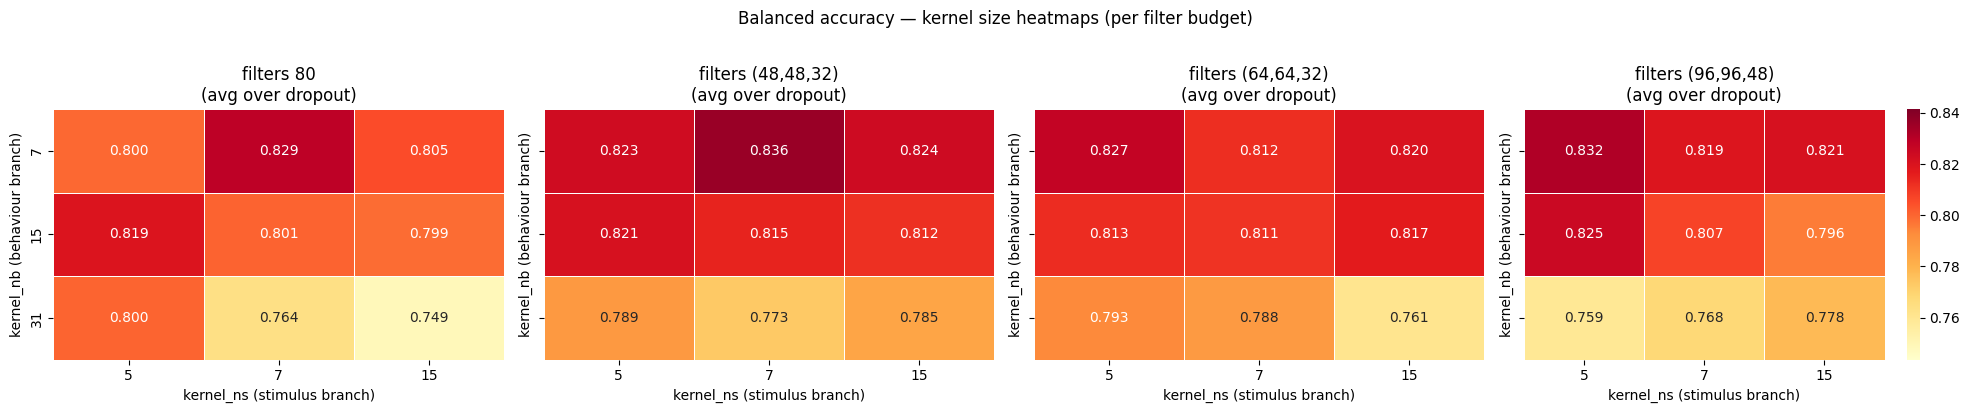

In [13]:
# One heatmap per filter budget; columns = kernel_ns, rows = kernel_nb
# Value = balanced_acc averaged over the two dropout values

filter_budgets = results_df['total_filters'].unique()
filter_labels  = {
    48:  '(32,32,16)',
    128: '(48,48,32)',
    160: '(64,64,32)',
    240: '(96,96,48)',
}

pivot_data = (
    results_df
    .groupby(['kernel_nb', 'kernel_ns', 'total_filters'])['balanced_acc']
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, len(filter_budgets),
                          figsize=(5 * len(filter_budgets), 4),
                          sharey=True)
if len(filter_budgets) == 1:
    axes = [axes]

vmin = pivot_data['balanced_acc'].min() - 0.005
vmax = pivot_data['balanced_acc'].max() + 0.005

for ax, fbudget in zip(axes, sorted(filter_budgets)):
    sub  = pivot_data[pivot_data['total_filters'] == fbudget]
    piv  = sub.pivot(index='kernel_nb', columns='kernel_ns', values='balanced_acc')
    sns.heatmap(
        piv, ax=ax, annot=True, fmt='.3f', cmap='YlOrRd',
        vmin=vmin, vmax=vmax, linewidths=0.5,
        cbar=(ax == axes[-1]),
    )
    ax.set_title(f'filters {filter_labels.get(fbudget, fbudget)}\n(avg over dropout)')
    ax.set_xlabel('kernel_ns (stimulus branch)')
    ax.set_ylabel('kernel_nb (behaviour branch)')

fig.suptitle('Balanced accuracy — kernel size heatmaps (per filter budget)', y=1.02)
plt.tight_layout()
plt.show()

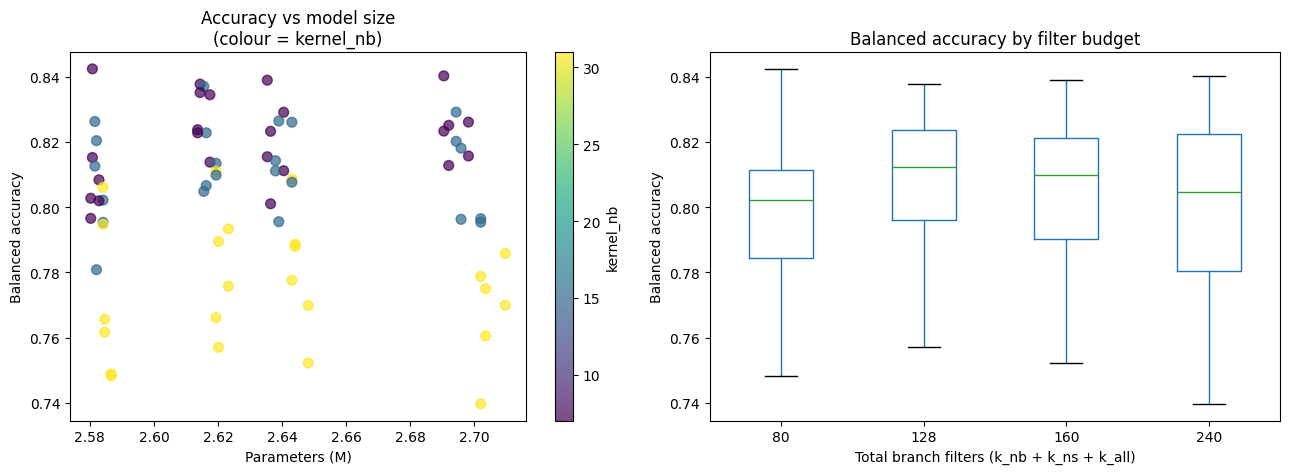


Marginal means — balanced_acc:

  kernel_nb:
                μ       σ    best
kernel_nb                        
7          0.8207  0.0133  0.8424
15         0.8112  0.0137  0.8371
31         0.7755  0.0197  0.8110

  kernel_ns:
                μ       σ    best
kernel_ns                        
5          0.8084  0.0239  0.8403
7          0.8019  0.0259  0.8424
15         0.7971  0.0251  0.8345

  total_filters:
                    μ       σ    best
total_filters                        
80             0.7961  0.0260  0.8424
128            0.8086  0.0241  0.8377
160            0.8047  0.0226  0.8389
240            0.8005  0.0275  0.8403

  dropout:
              μ       σ    best
dropout                        
0.3      0.8006  0.0279  0.8424
0.4      0.8044  0.0220  0.8377


In [14]:
# How does accuracy scale with model size?
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter balanced_acc vs n_params, coloured by kernel_nb
sc = axes[0].scatter(
    results_df['n_params'] / 1e6,
    results_df['balanced_acc'],
    c=results_df['kernel_nb'],
    cmap='viridis', alpha=0.7, s=50,
)
plt.colorbar(sc, ax=axes[0], label='kernel_nb')
axes[0].set_xlabel('Parameters (M)')
axes[0].set_ylabel('Balanced accuracy')
axes[0].set_title('Accuracy vs model size\n(colour = kernel_nb)')

# Right: box plot balanced_acc by total_filters
order = sorted(results_df['total_filters'].unique())
results_df.boxplot(
    column='balanced_acc', by='total_filters',
    ax=axes[1], grid=False,
)
axes[1].set_title('Balanced accuracy by filter budget')
axes[1].set_xlabel('Total branch filters (k_nb + k_ns + k_all)')
axes[1].set_ylabel('Balanced accuracy')
plt.suptitle('')   # remove auto title from boxplot

plt.tight_layout()
plt.show()

# Marginal means table
print('\nMarginal means — balanced_acc:')
for col in ['kernel_nb', 'kernel_ns', 'total_filters', 'dropout']:
    print(f'\n  {col}:')
    print(results_df.groupby(col)['balanced_acc']
          .agg(['mean','std','max'])
          .rename(columns={'mean':'μ','std':'σ','max':'best'})
          .round(4)
          .to_string())

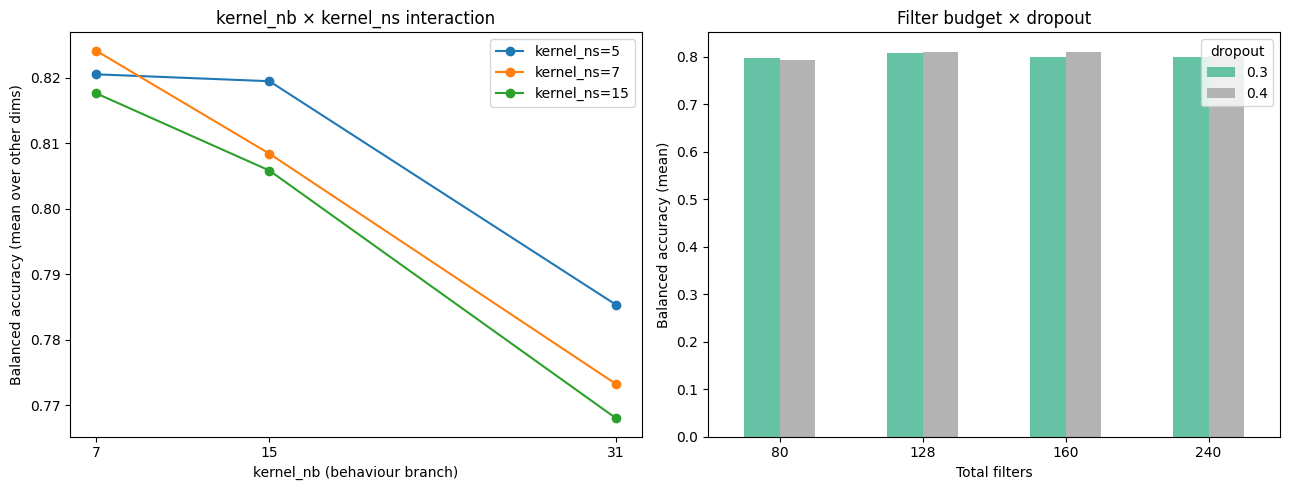

In [15]:
# Interaction: kernel_nb × kernel_ns marginal means (collapsed over filters & dropout)
pivot_k = (
    results_df
    .groupby(['kernel_nb', 'kernel_ns'])['balanced_acc']
    .mean()
    .unstack('kernel_ns')
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Line plot: kernel_nb on x, one line per kernel_ns
for kns in pivot_k.columns:
    axes[0].plot(pivot_k.index, pivot_k[kns], marker='o', label=f'kernel_ns={kns}')
axes[0].set_xlabel('kernel_nb (behaviour branch)')
axes[0].set_ylabel('Balanced accuracy (mean over other dims)')
axes[0].set_title('kernel_nb × kernel_ns interaction')
axes[0].legend()
axes[0].set_xticks(pivot_k.index)

# Bar chart: mean balanced_acc per filter budget with dropout breakdown
pivot_f = (
    results_df
    .groupby(['total_filters', 'dropout'])['balanced_acc']
    .mean()
    .unstack('dropout')
)
pivot_f.plot(kind='bar', ax=axes[1], rot=0, colormap='Set2')
axes[1].set_xlabel('Total filters')
axes[1].set_ylabel('Balanced accuracy (mean)')
axes[1].set_title('Filter budget × dropout')
axes[1].legend(title='dropout')

plt.tight_layout()
plt.show()

Best configuration:
config           knb7_kns7_f32-32-16_do0.3
kernel_nb                                7
kernel_ns                                7
total_filters                           80
dropout                                0.3
balanced_acc                       0.84241
macro_f1                          0.808377
n_params                           2580804

Retraining best config with full settings (patience=15, max_epochs=150)...
[knb7_kns7_f32-32-16_do0.3] Epoch   1 | train=1.2767  val=1.0971  acc=0.417
[knb7_kns7_f32-32-16_do0.3] Epoch   2 | train=1.1538  val=1.0740  acc=0.410
[knb7_kns7_f32-32-16_do0.3] Epoch   3 | train=1.1249  val=1.0701  acc=0.393
[knb7_kns7_f32-32-16_do0.3] Epoch   4 | train=1.1007  val=1.0646  acc=0.424
[knb7_kns7_f32-32-16_do0.3] Epoch   5 | train=1.0571  val=1.0431  acc=0.395
[knb7_kns7_f32-32-16_do0.3] Epoch   6 | train=1.0101  val=1.0173  acc=0.443
[knb7_kns7_f32-32-16_do0.3] Epoch   7 | train=0.9722  val=0.9854  acc=0.466
[knb7_kns7_f32-32-16_do0.3] 

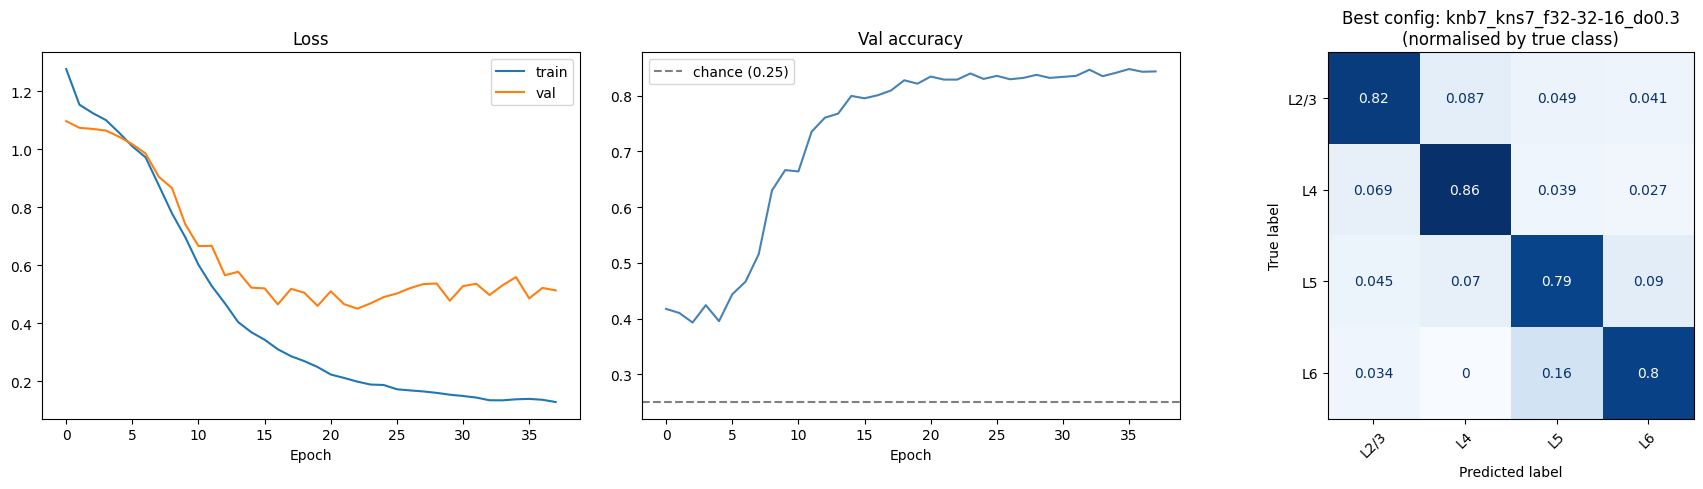

In [16]:
best = results_df.iloc[0]
print('Best configuration:')
print(best[['config','kernel_nb','kernel_ns','total_filters','dropout',
            'balanced_acc','macro_f1','n_params']].to_string())

best_model = FlexibleMultiStreamCNN(
    N_CHANNELS, TARGET_LEN, n_classes,
    k_nb=int(best['k_nb']), k_ns=int(best['k_ns']), k_all=int(best['k_all']),
    kernel_nb=int(best['kernel_nb']), kernel_ns=int(best['kernel_ns']), kernel_all=7,
    dropout=float(best['dropout']),
).to(DEVICE)

print(f'\nRetraining best config with full settings (patience=15, max_epochs=150)...')
history_best = train_model(
    best_model, train_loader, test_loader,
    max_epochs=150, patience=15,
    label=best['config'], verbose=True,
)

y_pred_best = evaluate(best_model, test_loader)
print(f'\nFinal evaluation:')
print(classification_report(y_test, y_pred_best, target_names=enc.classes_))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_best['train_loss'], label='train')
axes[0].plot(history_best['val_loss'],   label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history_best['val_acc'], color='steelblue')
axes[1].axhline(1/n_classes, color='grey', linestyle='--', label=f'chance ({1/n_classes:.2f})')
axes[1].set_title('Val accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=enc.classes_,
    xticks_rotation=45, cmap='Blues', normalize='true', colorbar=False, ax=axes[2],
)
axes[2].set_title(f'Best config: {best["config"]}\n(normalised by true class)')

plt.tight_layout()
plt.show()